![alternative text](../logo.png)

# EFAS Forecast: River Discharge Example

This notebook shows how to retrieve **EFAS flood forecast data** using the `efas-forecast` dataset, using
river discharge as an example.

In this example, you will:

1. Build and send a data request using a **bounding box** or a **polygon**
2. Decode the CoverageJSON data into an **xarray Dataset**
3. Visualise the data using the EarthKit plots package (Optional)

---

### What is EFAS?

**EFAS** (**E**uropean **F**lood **A**wareness **S**ystem) is the flood forecasting component of the
Copernicus Emergency Management Service. It runs the LISFLOOD hydrological model over a pan-European
river network and produces flood forecasts several days ahead, which national and regional authorities
use for early warning and civil-protection planning.

The `efas-forecast` dataset contains the operational medium-range forecasts. Each request returns one
field per **lead time** — the number of hours between the moment the forecast was produced and the time
it is valid for — so a single request gives you the whole forecast horizon.

Unlike the climate-projection datasets, EFAS is served from the **EWDS** (Early Warning Data Service)
rather than the CDS. This is handled automatically by the API, so the request looks the same.

More information about **available variables** and **request fields** can be found in:
- README and constraints/efas-forecast.json
- https://ewds.climate.copernicus.eu/datasets/efas-forecast?tab=overview


## Imports and shared settings

In [1]:
# Uncomment and run this cell if you need to install the dependencies
#!pip install -r requirements.txt

In [1]:
#Data requests and decode
import requests
from covjsonkit.api import Covjsonkit

#Data visualisation
import earthkit.plots as ekp

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="earthkit")

# API endpoint template
base_url = 'https://polytope-dss.ecmwf.int/api/v1/dataset/{dataset}/extract/'

headers = {
    'accept': 'application/json',
    'Content-Type': 'application/json',
}

---

## Example 1 – Bounding-box query

A **bounding box** selects all grid points inside a rectangular region defined by two corner coordinates.

In this example, we retrieve **river discharge in the last 6 hours** — the average volume of water
flowing past each grid point over a 6-hour window, in m³/s.

The bounding box covers the **Po valley** in northern Italy (roughly 44°N–46°N, 7°E–12.5°E), a densely
populated basin with a long history of flooding.

Note that we only specify the `variable`. Every other field is filled in by the API using its defaults:

- **date** – 31 days ago, the most recent available forecast
- **lead time** – `["24", "48", "72", "120", "240"]`, i.e. 1, 2, 3, 5 and 10 days ahead
- **product type** – `control_forecast`

The API returns data in **CoverageJSON** format.


### 1.1 Send the request

In [2]:
bbox_request = {
    'request': {
        'variable': ['river_discharge_in_the_last_6_hours'],
        # Optional – uncomment to pin a specific forecast date and lead times:
        # 'year': ['2025'],
        # 'month': ['06'],
        # 'day': ['01'],
        # 'leadtime_hour': ['24', '48', '72'],
    },
    'feature': {
        'type': 'boundingbox',
        # Coordinates are [lat_min, lon_min] and [lat_max, lon_max]
        'coordinates': [[44.0, 7.0], [46.0, 12.5]],
    },
}

url = base_url.format(dataset='efas-forecast')
response_bbox = requests.post(url, headers=headers, json=bbox_request)

#Print the response status code
print('Status:', response_bbox.status_code)

Status: 200


### 1.2 Decode the response

The module `covjsonkit` converts the downloaded CoverageJSON dataset into an [xarray Dataset](https://docs.xarray.dev/en/stable/), which gives us a labelled overview of the dataset and makes future post-processing straightforward.


In [3]:
decoder_bbox = Covjsonkit().decode(response_bbox.json())
ds_bbox = decoder_bbox.to_xarray()
ds_bbox

<xarray.Dataset> Size: 3MB
Dimensions:    (datetimes: 5, number: 1, steps: 1, points: 39600)
Coordinates:
  * datetimes  (datetimes) <U19 380B '2026-08-16T12:00:00' ... '2026-08-25T12...
  * number     (number) int64 8B 0
  * steps      (steps) int64 8B 0
  * points     (points) int64 317kB 0 1 2 3 4 ... 39595 39596 39597 39598 39599
    latitude   (points) float64 317kB 45.99 45.99 45.99 ... 44.01 44.01 44.01
    longitude  (points) float64 317kB 7.008 7.025 7.042 ... 12.46 12.48 12.49
    levelist   (points) float64 317kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Data variables:
    dis06      (datetimes, number, steps, points) float64 2MB 0.01953 ... 0.0166
Attributes:
    number:   0
    step:     0
    date:     2026-08-16T12:00:00

The variable is named `dis06` (the short name EFAS uses for 6-hourly river discharge). The
`datetimes` coordinate holds the **valid time** of each requested lead time, so the first entry is the
earliest forecast step and the last entry is 10 days ahead.


### 1.3 Visualise the data

In this example, we are going to plot the forecast river discharge over the Po valley at the first
forecast step.

We use **Earthkit Plots** package to visualise the data.
Please, find more information and documentation of the package here:
https://earthkit-plots.readthedocs.io


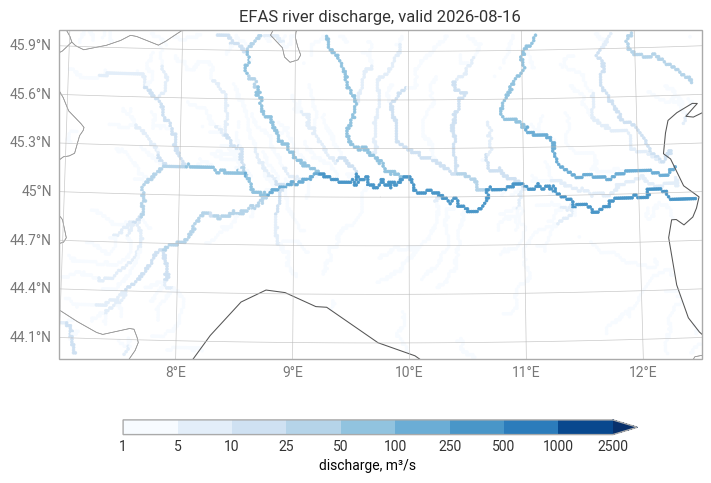

In [4]:
discharge_levels = [1, 5, 10, 25, 50, 100, 250, 500, 1000, 2500]

# Valid times of the returned forecast steps
valid_times = [str(t)[:10] for t in ds_bbox['datetimes'].values]

# A domain can also be given as explicit bounds: [lon_min, lon_max, lat_min, lat_max]
chart = ekp.Map(domain=[7.0, 12.5, 44.0, 46.0])
chart.point_cloud(ds_bbox['dis06'].isel(datetimes=0, number=0, steps=0),
    x=ds_bbox['longitude'],
    y=ds_bbox['latitude'],
    units='m3/s',
    s=4,
    style=ekp.Style(levels=discharge_levels, colors='Blues', extend="max"))

chart.coastlines()
chart.borders()
chart.gridlines()
chart.title(f'EFAS river discharge, valid {valid_times[0]}')
chart.legend(label='discharge, m³/s')

chart.show()

The Po and its tributaries are clearly visible as the darkest line of points running west to east
across the basin, with discharge increasing downstream as more and more catchment area drains into the
main channel.


---

## Example 2 – Polygon query

A **polygon** selects grid points inside an arbitrary shape. This is useful when
your area of interest follows administrative boundaries, a river catchment, or
any non-rectangular outline.

Rules for polygon coordinates:

- Each point is `[lat, lon]`
- The polygon must be **closed**: the first and last point must be identical
- At least 4 points are needed (3 unique corners + the closing repeat)

The polygon below roughly traces **Belgium**, which is drained by the Meuse and the Scheldt. Notice that
**only the `feature` block changes** – the `request` dict is the same as in the bounding box example.


### 2.1 Send the request

In [5]:
polygon_request = {
    'request': {
        'variable': ['river_discharge_in_the_last_6_hours'],
    },
    'feature': {
        'type': 'polygon',
        # Closed polygon of [lat, lon] pairs – first point must equal last point
        'coordinates': [[51.09, 2.54], [51.35, 3.35], [51.47, 4.53], [51.50, 5.05],
                        [51.19, 5.85], [50.75, 6.02], [50.32, 6.41], [49.80, 6.13],
                        [49.53, 5.82], [49.65, 5.45], [49.95, 4.85], [50.14, 4.15],
                        [50.50, 3.65], [50.78, 3.15], [50.79, 2.57], [51.09, 2.54]],
    },
}

url_poly = base_url.format(dataset='efas-forecast')
response_poly = requests.post(url_poly, headers=headers, json=polygon_request)

# Print the response status code
print('Status:', response_poly.status_code)

Status: 200


### 2.2 Decode the response

As in the previous example, we use `covjsonkit` module to convert the downloaded CoverageJSON dataset into an xarray.


In [6]:
decoder_poly = Covjsonkit().decode(response_poly.json())
ds_poly = decoder_poly.to_xarray()
ds_poly

<xarray.Dataset> Size: 1MB
Dimensions:    (datetimes: 5, number: 1, steps: 1, points: 15260)
Coordinates:
  * datetimes  (datetimes) <U19 380B '2026-08-16T12:00:00' ... '2026-08-25T12...
  * number     (number) int64 8B 0
  * steps      (steps) int64 8B 0
  * points     (points) int64 122kB 0 1 2 3 4 ... 15255 15256 15257 15258 15259
    latitude   (points) float64 122kB 51.49 51.49 51.49 ... 49.54 49.54 49.54
    longitude  (points) float64 122kB 4.908 4.925 4.942 ... 5.792 5.808 5.825
    levelist   (points) float64 122kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Data variables:
    dis06      (datetimes, number, steps, points) float64 610kB 0.01465 ... 0...
Attributes:
    number:   0
    step:     0
    date:     2026-08-16T12:00:00

### 2.3 Visualise the data

Here we plot the earliest step (24 hours ahead) and the latest one (10 days ahead) side by side.

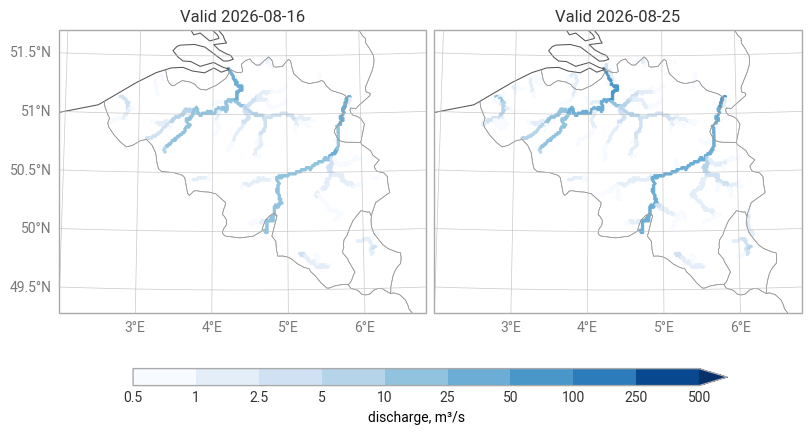

In [7]:
# Levels matched to this basin, roughly an order of magnitude below the Po
belgium_levels = [0.5, 1, 2.5, 5, 10, 25, 50, 100, 250, 500]

valid_times_poly = [str(t)[:10] for t in ds_poly['datetimes'].values]

figure = ekp.Figure(rows=1, columns=2, domain=[2.0, 6.8, 49.3, 51.7])

for step in [0, -1]:
    ax = figure.add_map()
    ax.point_cloud(ds_poly['dis06'].isel(datetimes=step, number=0, steps=0),
        x=ds_poly['longitude'],
        y=ds_poly['latitude'],
        units='m3/s',
        s=4,
        style=ekp.Style(levels=belgium_levels, colors='Blues', extend="max"))
    ax.title(f'Valid {valid_times_poly[step]}')

figure.coastlines()
figure.borders()
figure.gridlines()
figure.legend(label='discharge, m³/s')
figure.show()

Only the grid points inside the polygon are returned. Comparing the two panels shows how much water the forecast expects to move through the Meuse and
the Scheldt at the start and at the end of the forecast horizon - a main channel that darkens with lead time means water is building up in the basin.


---

## Next steps

Now that you can retrieve the data, here are some things to try next:

- **Swap the variable** – replace river discharge with any of the available
  variables (e.g. soil wetness index, snow depth water equivalent, runoff water equivalent)
- **Use the ensemble** – request `product_type: ['ensemble_perturbed_forecasts']` to get all
  ensemble members and plot the spread, which tells you how confident the forecast is
- **Pick your own lead times** – set `leadtime_hour` explicitly to follow a flood wave through the basin
  at 6-hourly resolution
- **Use a real boundary** – load a catchment or country shapefile and convert it to a
  polygon for the API

Please see the constraints file, which contains the valid values for the dataset.
